# Parameter estimation for translational protein sector

This notebook was used to estimate the parameters for the translational protein sector as used in the revised proteome allocation model. This notebook has been created to establish the parameters for Cornyebacterium glutanicum ATCC 13032. Experimental data was obtained from [Matamouros et al (2023)](https://www.nature.com/articles/s41467-023-41176-y#data-availability) Supplementary Data 9

### Author: Samira L. van den Bogaard
## Setting up the notebook environment¶

In [30]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cobra.io import read_sbml_model

if os.path.split(os.getcwd())[1] == 'i1_preprocessing':
    os.chdir('../..')
    

from PAModelpy import TransEnzymeSector, PAModel, Config
from Scripts.pam_generation_uniprot_id import setup_pputida_pam 
from Modules.utils.sector_config_functions import (perform_linear_regression,
                                                                        reset_translational_sector,
                                                                        plot_translational_protein_vs_mu,
                                                                        get_model_simulations_vs_sector,
                                                  )

In [42]:
DATA_FILE_PATH = os.path.join('Data', 'Cglutanicum_phenotypes', 
                              'cglutanicum_proteomics.xlsx')
# FUNCTIONAL_ANNOTATION_FILE_PATH =os.path.join('Data', 'Cglutanicum_phenotypes', 
#                                               'uniprotkb_taxonomy_id_196627_2025_01_30.xlsx')
MODEL_FILE_PATH = os.path.join('Models', 'iCGB21FR_annotated_copyable.xml')
PAM_DATA_FILE_PATH = os.path.join('Results', '1_preprocessing', 
                                  'proteinAllocationModel_iCGB21FR_EnzymaticData_250220.xlsx')
# METADATA_FILE_PATH = os.path.join('Data', 'Cglutanicum_phenotypes', 'growth-rates.csv')
RESULT_FIG_PATH = os.path.join('Results', '1_preprocessing',
                               'figures', 'SuppFig_translational_sector_cglutanicum.png')
OUTPUT_FILE_PATH = os.path.join('Results', '1_preprocessing', f'proteinAllocationModel_iCGB21FR_EnzymaticData_250220.xlsx')


MEASURED_PROTEIN_FRACTION = 1
# MEASURED_PROTEIN_FRACTION = 0.55*0.55#0.55 * 0.55 #measured proteome vs g_p/gcdw in Ecoli

GLC_UPTAKE_RXN_ID = 'EX_glc__D_e'
BIOMASS_RXN_ID = 'Growth'
MW_GLC = 180.15588 #g/mol
PRT_BMS_FRACTION = 0.5 #g_p/g_CDW (assumption)

config = Config()
config.reset()
config.BIOMASS_REACTION = 'Growth'

## Get the proteomics data 
The units of the ribosomal protein fraction are in g_ribosomes/g_protein. For the translational protein sector this has to be converted to g_ribosomes/g_CDW.

In [32]:
#get the validation data
df_proteomics = pd.read_excel(DATA_FILE_PATH, sheet_name = 'ribosome_fraction')
#filter out the stress conditions
df_proteomics

,Medium,growth_rate,growth_rate_error,ribosomal_protein_fraction,ribosomal_protein_fraction_error
0,BHI+CGXII+GLU+CAA,0.94,0.08,0.53,0.06
1,BHI+CGXII+GLU,0.77,0.07,0.43,0.05
2,BHI+GLU,0.61,0.02,0.23,0.03
3,CGXII+GLU,0.47,0.03,0.18,0.05
4,CGXII+ACE,0.40,0.01,0.15,0.02
5,CGXII+PYR,0.29,0.01,0.14,0.02
6,CGXII+EtOH+CAA,0.24,0.05,0.14,0.04
7,CGXII+LAC,0.27,0.07,0.12,0.02
8,CGXII+EtOH,0.12,0.01,0.11,0.02
9,CGXII+Glutamate,0.07,0.02,0.11,0.02


Text(0, 0.5, 'ribosomal fraction [$g_{ribosome}/g_{protein}$]')

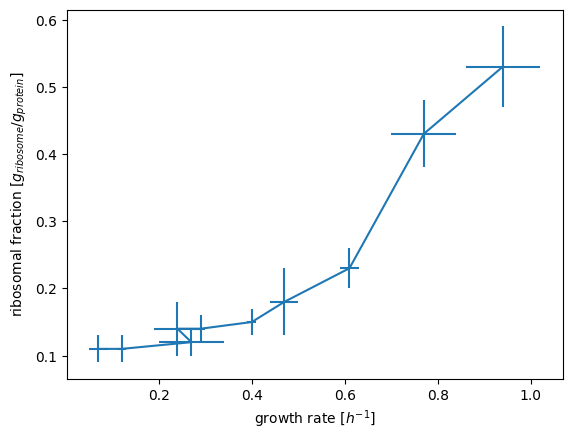

In [33]:
plt.errorbar(x = df_proteomics.growth_rate,
             y = df_proteomics.ribosomal_protein_fraction, 
             xerr = df_proteomics.growth_rate_error, 
             yerr = df_proteomics.ribosomal_protein_fraction_error
            )
plt.xlabel(r'growth rate [$h^{-1}$]')
plt.ylabel(r'ribosomal fraction [$g_{ribosome}/g_{protein}$]')

## Get the relationship between growth rate and total protein content
To convert the grams of protein to grams of cell dry weight, we need to know how much protein there is in the cell dry weight. Using the quantitative proteomics data from Lorenzo Wormer at the Karlsruhe institute of Technology, we can make an estimate. We only use the 'normal' growth conditions, without stressors.

In [34]:
protein_fractions_df = pd.read_excel(DATA_FILE_PATH, sheet_name = 'proteome_fraction')
protein_fractions_df = protein_fractions_df[:6]
protein_fractions_df

,condition,replicate,protein_mass,cdw,protein_fraction,growth_rate,growth_rate_error,condition_description
0,A,3,0.715247,2.4250,0.294947,0.470758,0.038449,Glu 4 %
1,B,3,1.409539,2.9375,0.479843,0.365737,0.013433,Medium / LB
2,C,3,2.049265,4.0625,0.504434,0.420190,0.016385,Medium / BHI
3,D,3,0.968195,1.5500,0.624642,0.450025,0.063295,Substrate / Glu 8 %
4,E,3,0.235623,0.6625,0.355657,0.258879,0.114236,Substrate / Glu + Ac
5,F,3,0.351101,0.6125,0.573226,0.243610,0.011023,Substrate / Ac 2 %


Text(0, 0.5, 'protein fraction [$g_{protein}/g_{CDW}$]')

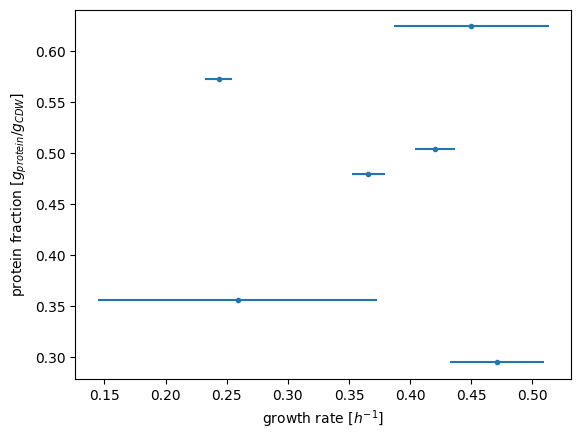

In [35]:
plt.errorbar(x = protein_fractions_df.growth_rate,
             y = protein_fractions_df.protein_fraction, 
             xerr = protein_fractions_df.growth_rate_error,
             ls = '',
             marker = '.'
            )
plt.xlabel(r'growth rate [$h^{-1}$]')
plt.ylabel(r'protein fraction [$g_{protein}/g_{CDW}$]')

## Get growth rate vs ribosomal protein relation
Only make use of the linear relation in the lower growth rate regime (<0.4, as described by [Matamouros et al (2023)](https://www.nature.com/articles/s41467-023-41176-y#data-availability))

In [36]:
#get the relation with growth rate
slope, intercept = perform_linear_regression(x=df_proteomics['growth_rate'][df_proteomics['growth_rate']<0.4], 
                                             y=df_proteomics['ribosomal_protein_fraction'][df_proteomics['growth_rate']<0.4]*PRT_BMS_FRACTION)

print('Translational sector vs growth rate using data from Schmidt et al (2016): \n Intercept: ',intercept, 'g/g_cdw')
print('Slope: ',slope, 'g/g_cdw/h')

Translational sector vs growth rate using data from Schmidt et al (2016): 
 Intercept:  0.04961193241816261 g/g_cdw
Slope:  0.0625659978880676 g/g_cdw/h


## Use the mu vs translational protein relationship to perform simulations with the PAM model
The predicted glucose uptake rates can be used to derive the relationship between glucose uptake and translational protein.

In [37]:
#set up model without total protein constraint to just model the linear relation between
id_list_tps = [BIOMASS_RXN_ID]
tps_0 = [intercept]  # g/gDW
tps_mu = [slope]  # g h/gDW 
molmass_tps = [405903.94]  # g/mol

# translational protein sector
translation_enzyme_sector = TransEnzymeSector(
            id_list=id_list_tps,
            tps_0=tps_0,
            tps_mu=tps_mu,
            mol_mass=molmass_tps,
        )

model = read_sbml_model(MODEL_FILE_PATH)
pamodel = PAModel(id_or_model = model,
                  p_tot=False, 
                  translational_sector = translation_enzyme_sector,
                  configuration = config,
                  sensitivity = False) # sensitivity disabled to speed things up
#get parameters
translational_sector = pamodel.sectors.get_by_id('TranslationalProteinSector')
tps_molmass = translational_sector.mol_mass[0]

#adjust relation in model
trans_sector = pamodel.sectors.get_by_id('TranslationalProteinSector')

#adjust the translational protein sector
pamodel.change_sector_parameters(trans_sector, slope*MEASURED_PROTEIN_FRACTION,
                                 intercept*MEASURED_PROTEIN_FRACTION, lin_rxn_id = BIOMASS_RXN_ID)

Setting up the proteome allocation model iCBG21FR

Total condition-dependent protein constraint is not added 

Add the following protein sector: TranslationalProteinSector

Done with setting up the proteome allocation model iCBG21FR



In [38]:
#run the model
substrate_range = np.arange(-20,1,1)

#we shouldn't correct for measured total protein here, as we are comparing it to the measured data
simulation_results_bms = get_model_simulations_vs_sector(pamodel, GLC_UPTAKE_RXN_ID, BIOMASS_RXN_ID,
                                           substrate_range, intercept,slope) 


Running simulations with  -20 mmol/g_cdw/h of substrate going into the system
Running simulations with  -19 mmol/g_cdw/h of substrate going into the system
Running simulations with  -18 mmol/g_cdw/h of substrate going into the system
Running simulations with  -17 mmol/g_cdw/h of substrate going into the system
Running simulations with  -16 mmol/g_cdw/h of substrate going into the system
Running simulations with  -15 mmol/g_cdw/h of substrate going into the system
Running simulations with  -14 mmol/g_cdw/h of substrate going into the system
Running simulations with  -13 mmol/g_cdw/h of substrate going into the system
Running simulations with  -12 mmol/g_cdw/h of substrate going into the system
Running simulations with  -11 mmol/g_cdw/h of substrate going into the system
Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -9 mmol/g_cdw/h of substrate going into the system
Running simulations with  -8 mmol/g_cdw/h of substrate going into

In [39]:
#derive the relation to glucose uptake rate
#results are in g_transprot/g_prot and need to be converted to g/gcdw (glucose uptake should stay in mmol for compatibility with model)
slope_glc, intercept_glc = perform_linear_regression(
    x=simulation_results_bms[GLC_UPTAKE_RXN_ID], y=simulation_results_bms['translational_protein'])

print('Translational sector vs glucose uptake using data from Schmidt et al (2016): \n Intercept: ',intercept_glc *MEASURED_PROTEIN_FRACTION, ' g/g_cdw')
print('Slope: ',slope_glc*MEASURED_PROTEIN_FRACTION, ' g/mmol_glucose/h')


Translational sector vs glucose uptake using data from Schmidt et al (2016): 
 Intercept:  0.06599595559071678  g/g_cdw
Slope:  -0.0018628725719772247  g/mmol_glucose/h


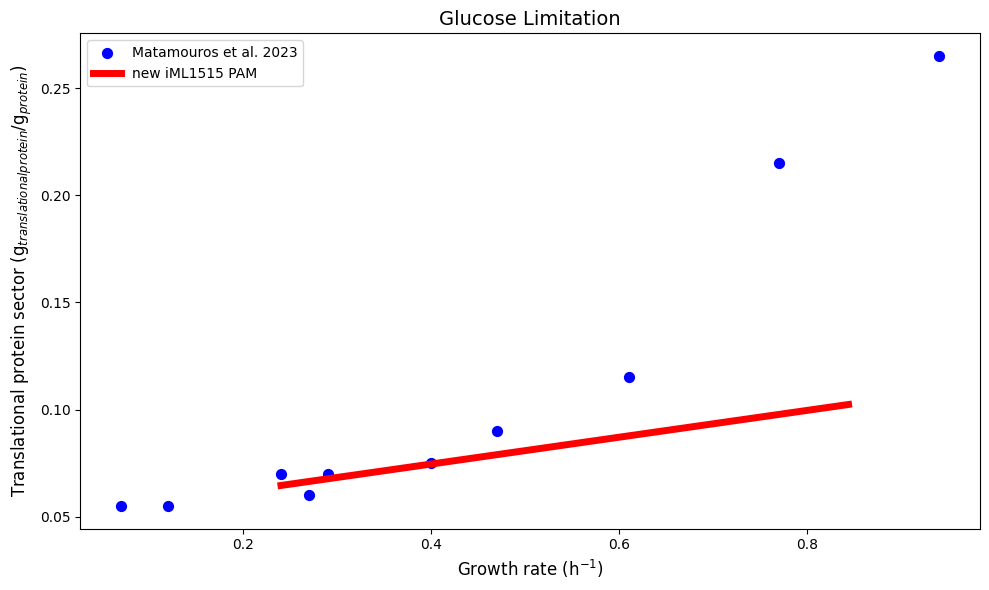

In [40]:
df_proteomics_to_plot = df_proteomics.rename({'growth_rate': 'Experimental Growth rate',
                                              'ribosomal_protein_fraction': 'Translation, ribosomal structure and biogenesis'
                                             }, axis = 1)
df_proteomics_to_plot['Translation, ribosomal structure and biogenesis'] = df_proteomics_to_plot['Translation, ribosomal structure and biogenesis']*100

plot_translational_protein_vs_mu(df_proteomics_to_plot, simulation_results_bms, 
                                 protein_fraction = 1, 
                                 measured_protein_fraction=PRT_BMS_FRACTION,
                                 configuration = config,
                                 literature_label = 'Matamouros et al. 2023',
                                 oxygen_results = None)

## Save the new model parameters

In [43]:
# Get the information about the enzyme sectors
translational_sector = pd.read_excel(OUTPUT_FILE_PATH,
                                 sheet_name = 'Translational').set_index('Parameter')

# adjust unused enzymes information
translational_sector.loc['id_list', 'Value'] = 'EX_glc__D_e'
translational_sector.loc['tps_mu', 'Value'] = slope_glc*MEASURED_PROTEIN_FRACTION
translational_sector.loc['tps_0', 'Value'] = intercept_glc *MEASURED_PROTEIN_FRACTION

with pd.ExcelWriter(OUTPUT_FILE_PATH,
                    mode = 'a',engine='openpyxl',
                    if_sheet_exists= 'replace'
                   ) as writer:
    translational_sector.to_excel(writer, sheet_name='Translational')